# **Import**

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# **Validação Base**

In [2]:
base = pd.read_parquet("base.parquet")

In [3]:
base.head()

,semana,preco_rs_medio,preco_rs_fechamento,preco_usd_medio,preco_usd_fechamento,retorno_rs_1w,retorno_usd_1w,dolar_medio_semana,dolar_fechamento_semana,chuva_soja_1w,...,mes,fase_soja,periodo_critico_soja,export_volume_ton_lag_1m,export_valor_fob_usd_lag_1m,export_preco_implicito_usd_ton_lag_1m,safra_ref,conab_area_mil_ha,conab_produtividade_kg_ha,conab_producao_mil_ton
0,2016-06-10,96.100,96.88,28.044,28.26,0.006441,0.035544,3.43638,3.4261,17.4756,...,6,entressafra,0,9915098.848,3600309132,363.113791,2015/16,33251.9,2877.958999,95697.60484
1,2016-06-17,97.100,96.78,28.026,28.28,-0.001032,0.000708,3.46832,3.4372,2.0682,...,6,entressafra,0,9915098.848,3600309132,363.113791,2015/16,33251.9,2877.958999,95697.60484
2,2016-06-24,94.408,92.66,27.936,27.46,-0.042571,-0.028996,3.37840,3.3772,3.0711,...,6,entressafra,0,9915098.848,3600309132,363.113791,2015/16,33251.9,2877.958999,95697.60484
3,2016-07-01,92.968,92.31,28.384,28.57,-0.003777,0.040422,3.28064,3.2298,0.0401,...,7,entressafra,0,7761036.427,2971369089,382.857253,2015/16,33251.9,2877.958999,95697.60484
4,2016-07-08,90.066,87.65,27.218,26.66,-0.050482,-0.066853,3.29964,3.2968,4.6174,...,7,entressafra,0,7761036.427,2971369089,382.857253,2015/16,33251.9,2877.958999,95697.60484


In [4]:
base.tail()

,semana,preco_rs_medio,preco_rs_fechamento,preco_usd_medio,preco_usd_fechamento,retorno_rs_1w,retorno_usd_1w,dolar_medio_semana,dolar_fechamento_semana,chuva_soja_1w,...,mes,fase_soja,periodo_critico_soja,export_volume_ton_lag_1m,export_valor_fob_usd_lag_1m,export_preco_implicito_usd_ton_lag_1m,safra_ref,conab_area_mil_ha,conab_produtividade_kg_ha,conab_producao_mil_ton
516,2026-05-01,128.5275,128.88,25.8025,26.00,0.008924,0.017613,4.986225,4.9886,25.6711,...,5,entressafra,0,1.675609e+07,6965956360,415.72688,2025/26,48716.5,3697.506826,180129.6
517,2026-05-08,128.3500,127.70,26.0720,26.09,-0.009156,0.003462,4.925440,4.8999,9.1720,...,5,entressafra,0,1.675609e+07,6965956360,415.72688,2025/26,48716.5,3697.506826,180129.6
518,2026-05-15,129.2800,129.14,26.0280,25.50,0.011276,-0.022614,4.950620,5.0654,19.8176,...,5,entressafra,0,1.675609e+07,6965956360,415.72688,2025/26,48716.5,3697.506826,180129.6
519,2026-05-22,129.7580,129.62,25.8780,25.80,0.003717,0.011765,5.019780,5.0140,12.6527,...,5,entressafra,0,1.675609e+07,6965956360,415.72688,2025/26,48716.5,3697.506826,180129.6
520,2026-05-29,130.0580,130.12,25.8220,25.79,0.003857,-0.000388,5.038960,5.0569,5.3182,...,5,entressafra,0,1.675609e+07,6965956360,415.72688,2025/26,48716.5,3697.506826,180129.6


In [5]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   semana                                 521 non-null    datetime64[ns]
 1   preco_rs_medio                         521 non-null    float64       
 2   preco_rs_fechamento                    521 non-null    float64       
 3   preco_usd_medio                        521 non-null    float64       
 4   preco_usd_fechamento                   521 non-null    float64       
 5   retorno_rs_1w                          521 non-null    float64       
 6   retorno_usd_1w                         521 non-null    float64       
 7   dolar_medio_semana                     521 non-null    float64       
 8   dolar_fechamento_semana                521 non-null    float64       
 9   chuva_soja_1w                          521 non-null    float64   

In [6]:
base.shape

(521, 23)

In [7]:
base.isna().sum()

,0
semana,0
preco_rs_medio,0
preco_rs_fechamento,0
preco_usd_medio,0
preco_usd_fechamento,0
retorno_rs_1w,0
retorno_usd_1w,0
dolar_medio_semana,0
dolar_fechamento_semana,0
chuva_soja_1w,0


In [8]:
base.duplicated(['semana']).sum()

np.int64(0)

In [9]:
print(base['semana'].min(), base['semana'].max())

2016-06-10 00:00:00 2026-05-29 00:00:00


# **EDA Temporal**

## **Série histórica do preço médio**

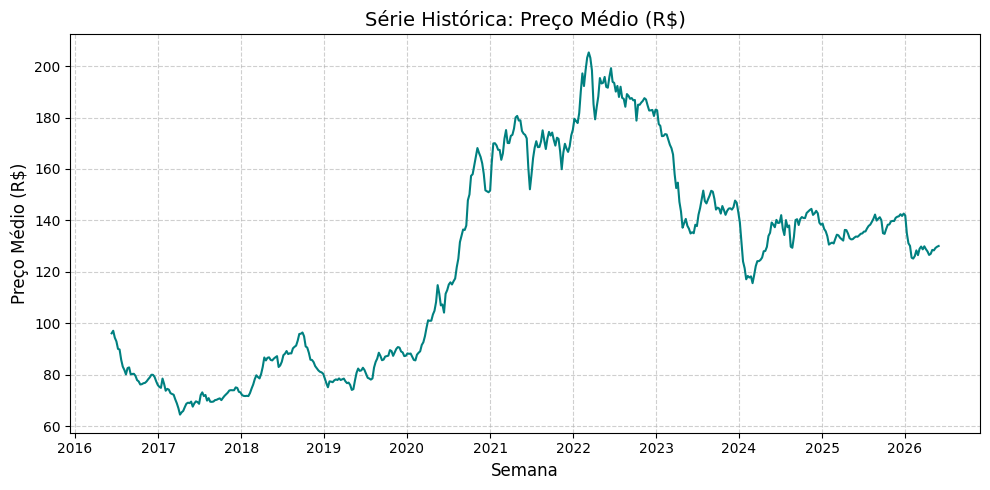

In [10]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=base, x='semana', y='preco_rs_medio', color='teal')
plt.title('Série Histórica: Preço Médio (R$)', fontsize=14)
plt.xlabel('Semana', fontsize=12)
plt.ylabel('Preço Médio (R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

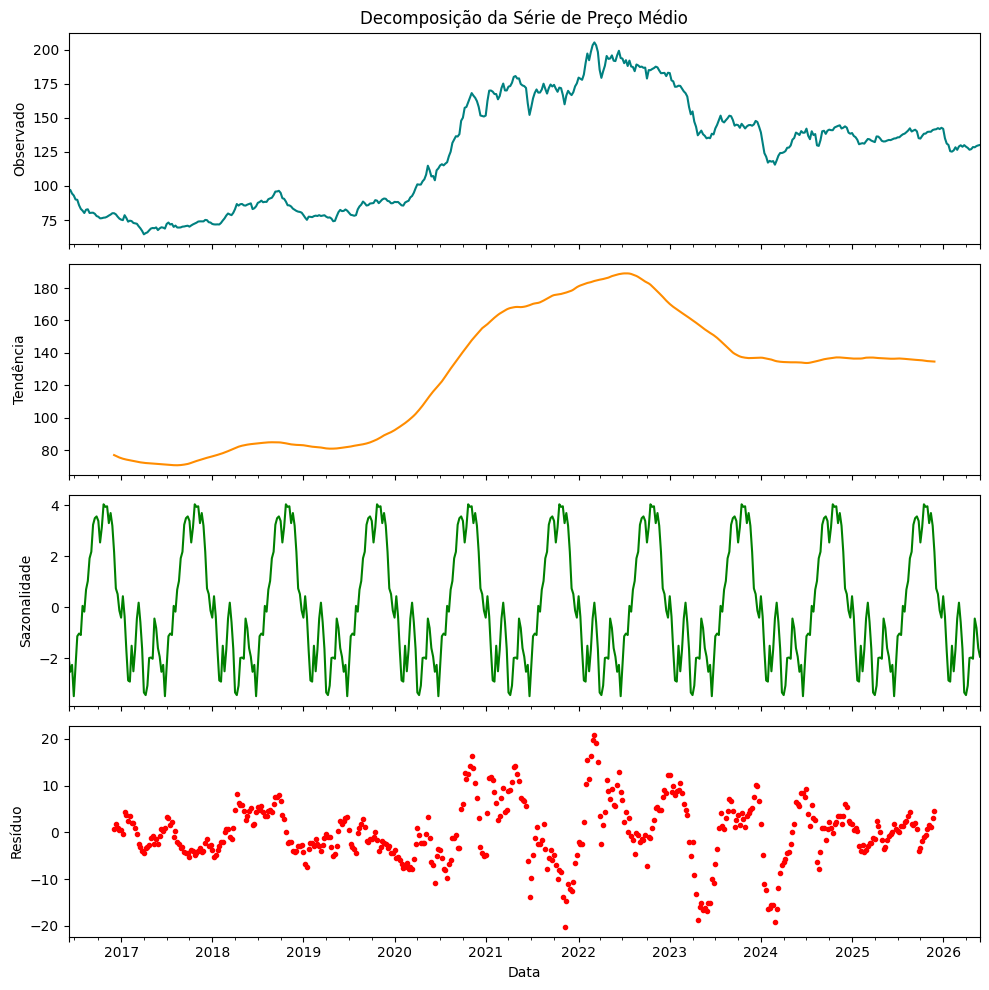

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

base_ts = base.set_index('semana')['preco_rs_medio']

decomposition = seasonal_decompose(base_ts, model='additive', period=52)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

decomposition.observed.plot(ax=ax1, color='teal')
ax1.set_ylabel('Observado')
ax1.set_title('Decomposição da Série de Preço Médio')

decomposition.trend.plot(ax=ax2, color='darkorange')
ax2.set_ylabel('Tendência')

decomposition.seasonal.plot(ax=ax3, color='green')
ax3.set_ylabel('Sazonalidade')

decomposition.resid.plot(ax=ax4, color='red', style='.')
ax4.set_ylabel('Resíduo')

plt.xlabel('Data')
plt.tight_layout()
plt.show()

In [19]:
data_menor_preco = base[base['preco_rs_medio'] == base['preco_rs_medio'].min()]
data_maior_preco = base[base['preco_rs_medio'] == base['preco_rs_medio'].max()]

print('Menor preço historico (Reais): ' + str(base['preco_rs_medio'].min()) + ' em ' + str(data_menor_preco['semana'].values[0]))
print('Maior preço historico (Reais): ' + str(base['preco_rs_medio'].max()) + ' em ' + str(data_maior_preco['semana'].values[0]))

print('Aumento percentual no periodo final e inicial: ' + str(round(((base['preco_rs_medio'].iloc[-1] - base['preco_rs_medio'].iloc[0]) / base['preco_rs_medio'].iloc[0]) * 100, 2)) + '%)')

Menor preço historico (Reais): 64.498 em 2017-04-07T00:00:00.000000000
Maior preço historico (Reais): 205.3 em 2022-03-11T00:00:00.000000000
Aumento percentual no periodo final e inicial: 35.34%)


## Preço em Reais x Preço em Dolar

In [20]:
base.head()

,semana,preco_rs_medio,preco_rs_fechamento,preco_usd_medio,preco_usd_fechamento,retorno_rs_1w,retorno_usd_1w,dolar_medio_semana,dolar_fechamento_semana,chuva_soja_1w,...,mes,fase_soja,periodo_critico_soja,export_volume_ton_lag_1m,export_valor_fob_usd_lag_1m,export_preco_implicito_usd_ton_lag_1m,safra_ref,conab_area_mil_ha,conab_produtividade_kg_ha,conab_producao_mil_ton
0,2016-06-10,96.100,96.88,28.044,28.26,0.006441,0.035544,3.43638,3.4261,17.4756,...,6,entressafra,0,9915098.848,3600309132,363.113791,2015/16,33251.9,2877.958999,95697.60484
1,2016-06-17,97.100,96.78,28.026,28.28,-0.001032,0.000708,3.46832,3.4372,2.0682,...,6,entressafra,0,9915098.848,3600309132,363.113791,2015/16,33251.9,2877.958999,95697.60484
2,2016-06-24,94.408,92.66,27.936,27.46,-0.042571,-0.028996,3.37840,3.3772,3.0711,...,6,entressafra,0,9915098.848,3600309132,363.113791,2015/16,33251.9,2877.958999,95697.60484
3,2016-07-01,92.968,92.31,28.384,28.57,-0.003777,0.040422,3.28064,3.2298,0.0401,...,7,entressafra,0,7761036.427,2971369089,382.857253,2015/16,33251.9,2877.958999,95697.60484
4,2016-07-08,90.066,87.65,27.218,26.66,-0.050482,-0.066853,3.29964,3.2968,4.6174,...,7,entressafra,0,7761036.427,2971369089,382.857253,2015/16,33251.9,2877.958999,95697.60484


In [21]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   semana                                 521 non-null    datetime64[ns]
 1   preco_rs_medio                         521 non-null    float64       
 2   preco_rs_fechamento                    521 non-null    float64       
 3   preco_usd_medio                        521 non-null    float64       
 4   preco_usd_fechamento                   521 non-null    float64       
 5   retorno_rs_1w                          521 non-null    float64       
 6   retorno_usd_1w                         521 non-null    float64       
 7   dolar_medio_semana                     521 non-null    float64       
 8   dolar_fechamento_semana                521 non-null    float64       
 9   chuva_soja_1w                          521 non-null    float64   

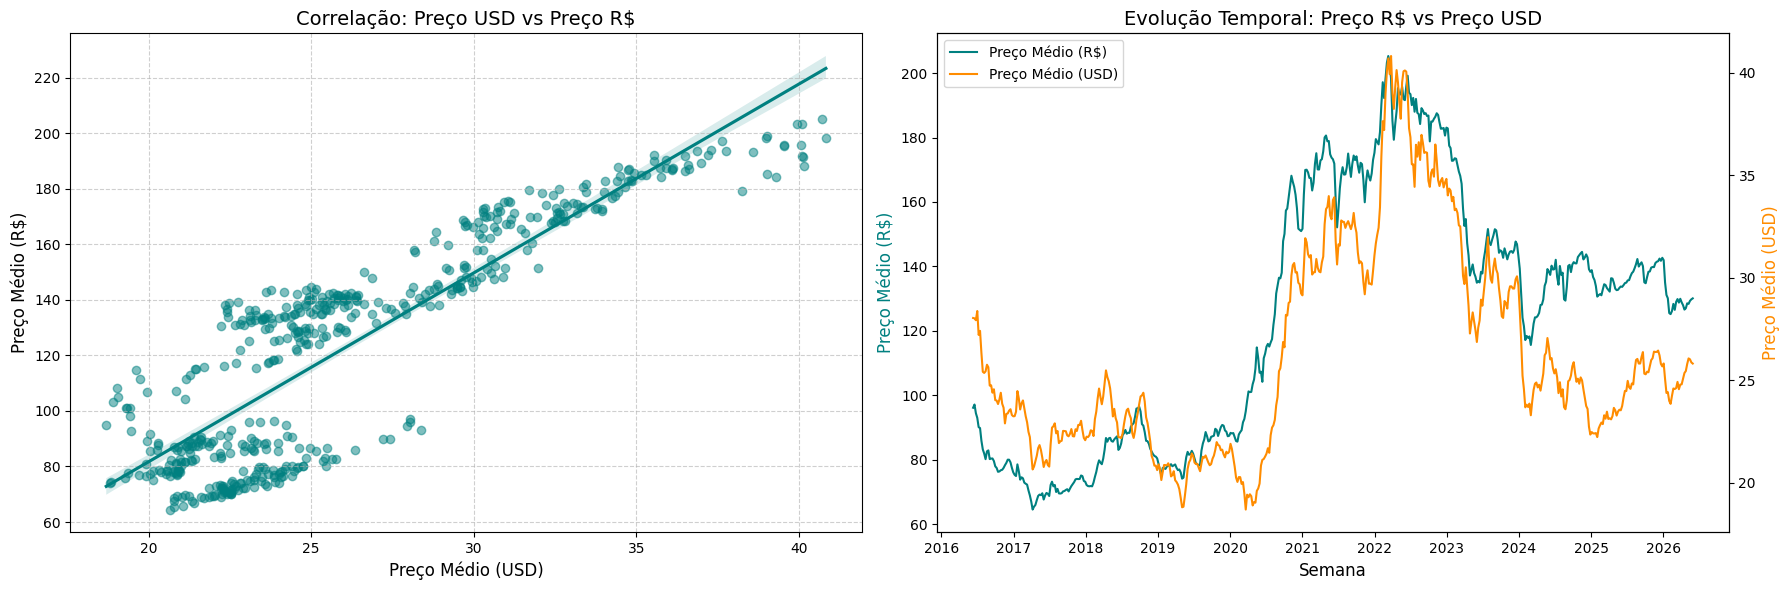

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando a figura com dois subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# 1. Gráfico de Dispersão (Correlação entre Preço R$ e Preço USD)
sns.regplot(data=base, x='preco_usd_medio', y='preco_rs_medio', ax=ax1, color='teal', scatter_kws={'alpha':0.5})
ax1.set_title('Correlação: Preço USD vs Preço R$', fontsize=14)
ax1.set_xlabel('Preço Médio (USD)', fontsize=12)
ax1.set_ylabel('Preço Médio (R$)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# 2. Série Temporal com Eixos Duplos (R$ vs USD)
ax2_twin = ax2.twinx()

line1 = sns.lineplot(data=base, x='semana', y='preco_rs_medio', ax=ax2, color='teal', label='Preço Médio (R$)')
line2 = sns.lineplot(data=base, x='semana', y='preco_usd_medio', ax=ax2_twin, color='darkorange', label='Preço Médio (USD)')

ax2.set_title('Evolução Temporal: Preço R$ vs Preço USD', fontsize=14)
ax2.set_xlabel('Semana', fontsize=12)
ax2.set_ylabel('Preço Médio (R$)', color='teal', fontsize=12)
ax2_twin.set_ylabel('Preço Médio (USD)', color='darkorange', fontsize=12)

# Ajustando as legendas
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')
ax2_twin.get_legend().remove()

plt.tight_layout()
plt.show()

## Retorno Semanal

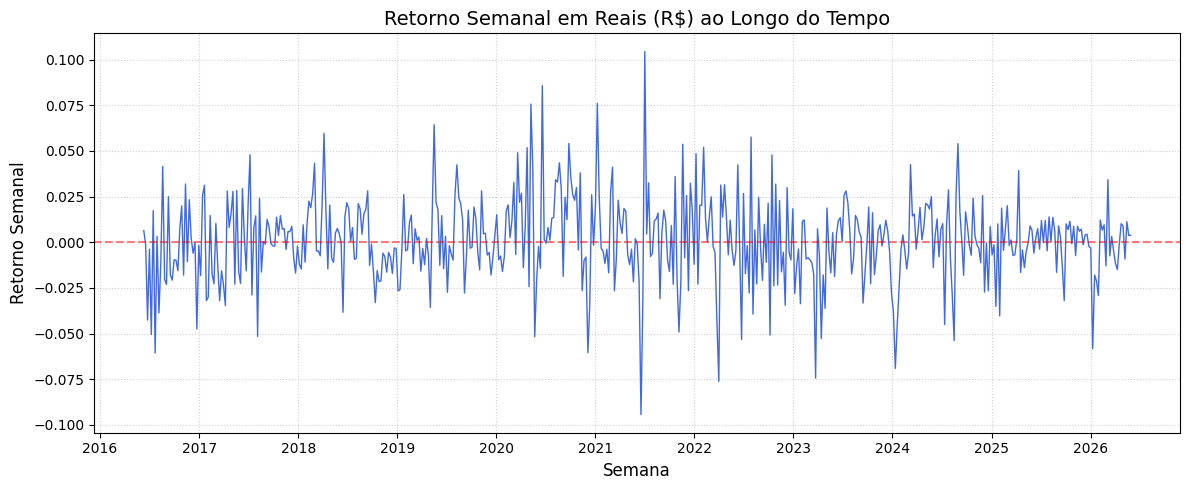

In [24]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=base, x='semana', y='retorno_rs_1w', color='royalblue', linewidth=1)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Retorno Semanal em Reais (R$) ao Longo do Tempo', fontsize=14)
plt.xlabel('Semana', fontsize=12)
plt.ylabel('Retorno Semanal', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [26]:
# Identificando os 5 maiores e 5 menores retornos semanais
top_5_altas = base.nlargest(5, 'retorno_rs_1w')[['semana', 'retorno_rs_1w']]
top_5_quedas = base.nsmallest(5, 'retorno_rs_1w')[['semana', 'retorno_rs_1w']]

print("--- 5 MAIORES ALTAS SEMANAIS ---")
for i, row in top_5_altas.iterrows():
    print(f"{row['semana'].date()}: {row['retorno_rs_1w']*100:.2f}%")

print("\n--- 5 MAIORES QUEDAS SEMANAIS ---")
for i, row in top_5_quedas.iterrows():
    print(f"{row['semana'].date()}: {row['retorno_rs_1w']*100:.2f}%")

--- 5 MAIORES ALTAS SEMANAIS ---
2021-07-02: 10.45%
2020-06-19: 8.58%
2021-01-08: 7.61%
2020-05-08: 7.57%
2019-05-17: 6.44%

--- 5 MAIORES QUEDAS SEMANAIS ---
2021-06-18: -9.43%
2022-04-01: -7.62%
2023-03-24: -7.44%
2024-01-12: -6.91%
2016-07-22: -6.07%


A soja apresenta retornos semanais concentrados próximos de zero, porém com caudas longas e eventos extremos ocasionais, indicando comportamento típico de commodity sujeita a choques cambiais, climáticos e de mercado externo.

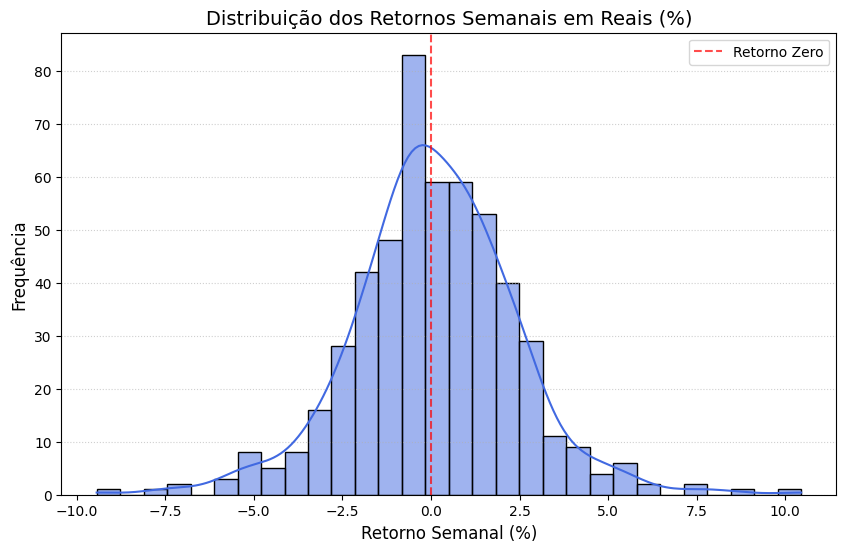

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(base['retorno_rs_1w'] * 100, bins=30, kde=True, color='royalblue')
plt.axvline(0, color='red', linestyle='--', alpha=0.7, label='Retorno Zero')
plt.title('Distribuição dos Retornos Semanais em Reais (%)', fontsize=14)
plt.xlabel('Retorno Semanal (%)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

In [28]:
base['retorno_rs_1w'].skew()

np.float64(0.031916680671980203)

# **EDA Variaveis**

## Exportações

In [32]:
base.head()

,semana,preco_rs_medio,preco_rs_fechamento,preco_usd_medio,preco_usd_fechamento,retorno_rs_1w,retorno_usd_1w,dolar_medio_semana,dolar_fechamento_semana,chuva_soja_1w,...,mes,fase_soja,periodo_critico_soja,export_volume_ton_lag_1m,export_valor_fob_usd_lag_1m,export_preco_implicito_usd_ton_lag_1m,safra_ref,conab_area_mil_ha,conab_produtividade_kg_ha,conab_producao_mil_ton
0,2016-06-10,96.100,96.88,28.044,28.26,0.006441,0.035544,3.43638,3.4261,17.4756,...,6,entressafra,0,9915098.848,3600309132,363.113791,2015/16,33251.9,2877.958999,95697.60484
1,2016-06-17,97.100,96.78,28.026,28.28,-0.001032,0.000708,3.46832,3.4372,2.0682,...,6,entressafra,0,9915098.848,3600309132,363.113791,2015/16,33251.9,2877.958999,95697.60484
2,2016-06-24,94.408,92.66,27.936,27.46,-0.042571,-0.028996,3.37840,3.3772,3.0711,...,6,entressafra,0,9915098.848,3600309132,363.113791,2015/16,33251.9,2877.958999,95697.60484
3,2016-07-01,92.968,92.31,28.384,28.57,-0.003777,0.040422,3.28064,3.2298,0.0401,...,7,entressafra,0,7761036.427,2971369089,382.857253,2015/16,33251.9,2877.958999,95697.60484
4,2016-07-08,90.066,87.65,27.218,26.66,-0.050482,-0.066853,3.29964,3.2968,4.6174,...,7,entressafra,0,7761036.427,2971369089,382.857253,2015/16,33251.9,2877.958999,95697.60484


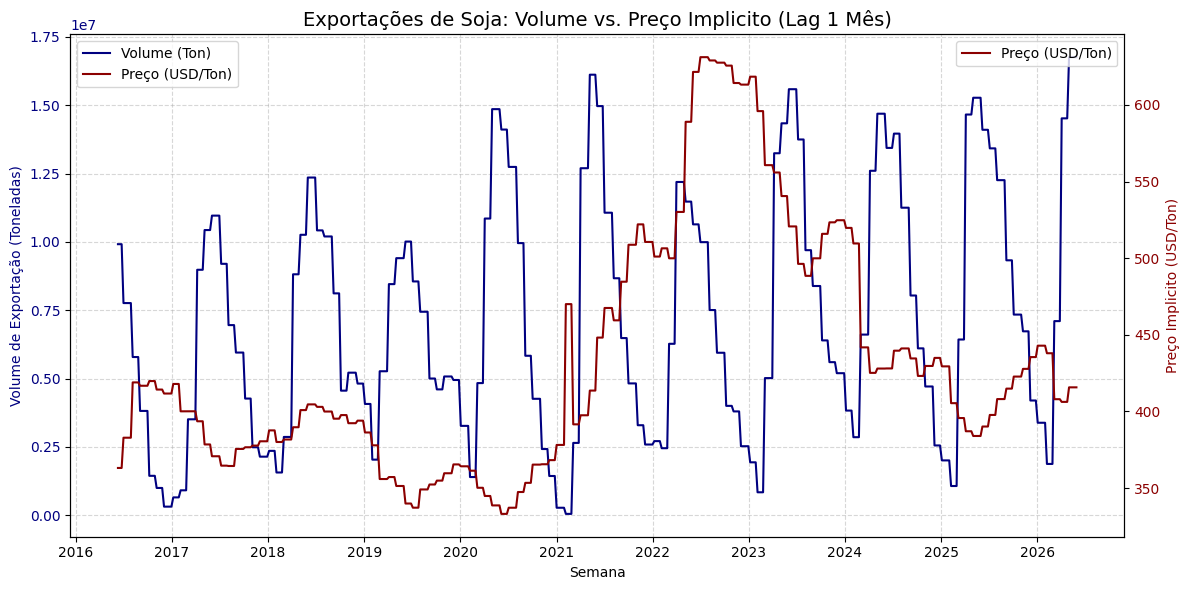

In [34]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo 1: Volume de Exportação
color_vol = 'navy'
sns.lineplot(data=base, x='semana', y='export_volume_ton_lag_1m', ax=ax1, color=color_vol, label='Volume (Ton)')
ax1.set_xlabel('Semana')
ax1.set_ylabel('Volume de Exportação (Toneladas)', color=color_vol)
ax1.tick_params(axis='y', labelcolor=color_vol)
ax1.grid(True, linestyle='--', alpha=0.5)

# Eixo 2: Preço Implicito
ax2 = ax1.twinx()
color_price = 'darkred'
sns.lineplot(data=base, x='semana', y='export_preco_implicito_usd_ton_lag_1m', ax=ax2, color=color_price, label='Preço (USD/Ton)')
ax2.set_ylabel('Preço Implicito (USD/Ton)', color=color_price)
ax2.tick_params(axis='y', labelcolor=color_price)

plt.title('Exportações de Soja: Volume vs. Preço Implicito (Lag 1 Mês)', fontsize=14)

# Combinando as legendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [37]:
correlacao_exportacoes = base[['export_volume_ton_lag_1m', 'export_preco_implicito_usd_ton_lag_1m']].corr()
correlacao_exportacoes

,export_volume_ton_lag_1m,export_preco_implicito_usd_ton_lag_1m
export_volume_ton_lag_1m,1.000000,-0.052716
export_preco_implicito_usd_ton_lag_1m,-0.052716,1.000000


In [42]:
maiores_meses_exportacoes = base.nlargest(15, 'export_volume_ton_lag_1m')[['semana', 'export_volume_ton_lag_1m']]
maiores_meses_exportacoes

,semana,export_volume_ton_lag_1m
516,2026-05-01,1.675609e+07
517,2026-05-08,1.675609e+07
518,2026-05-15,1.675609e+07
519,2026-05-22,1.675609e+07
520,2026-05-29,1.675609e+07
256,2021-05-07,1.611494e+07
257,2021-05-14,1.611494e+07
258,2021-05-21,1.611494e+07
259,2021-05-28,1.611494e+07
364,2023-06-02,1.558422e+07


In [43]:
import pandas as pd

# Criando colunas de Ano e Mês para o agrupamento
base['ano'] = base['semana'].dt.year
base['mes_nome'] = base['semana'].dt.month

# Agrupando por Ano e Mês para obter o volume mensal
# Usamos a média (mean) porque o volume de exportação (lag_1m) é repetido para todas as semanas do mesmo mês
export_mensal = base.groupby(['ano', 'mes_nome'])['export_volume_ton_lag_1m'].mean().reset_index()

# Identificando os 3 maiores meses para cada ano
top_3_por_ano = export_mensal.sort_values(['ano', 'export_volume_ton_lag_1m'], ascending=[True, False]).groupby('ano').head(3)

# Exibindo o resultado formatado
display(top_3_por_ano.rename(columns={'mes_nome': 'Mes', 'export_volume_ton_lag_1m': 'Volume_Medio'}))

,ano,Mes,Volume_Medio
0,2016,6,9.915099e+06
1,2016,7,7.761036e+06
2,2016,8,5.787203e+06
12,2017,6,1.095986e+07
11,2017,5,1.043213e+07
13,2017,7,9.196882e+06
24,2018,6,1.235317e+07
25,2018,7,1.042013e+07
23,2018,5,1.025864e+07
36,2019,6,1.001134e+07


In [44]:
from statsmodels.tsa.seasonal import seasonal_decompose

base_exp = base.set_index('semana')['export_volume_ton_lag_1m']

decomposition = seasonal_decompose(base_exp, model='additive', period=52)

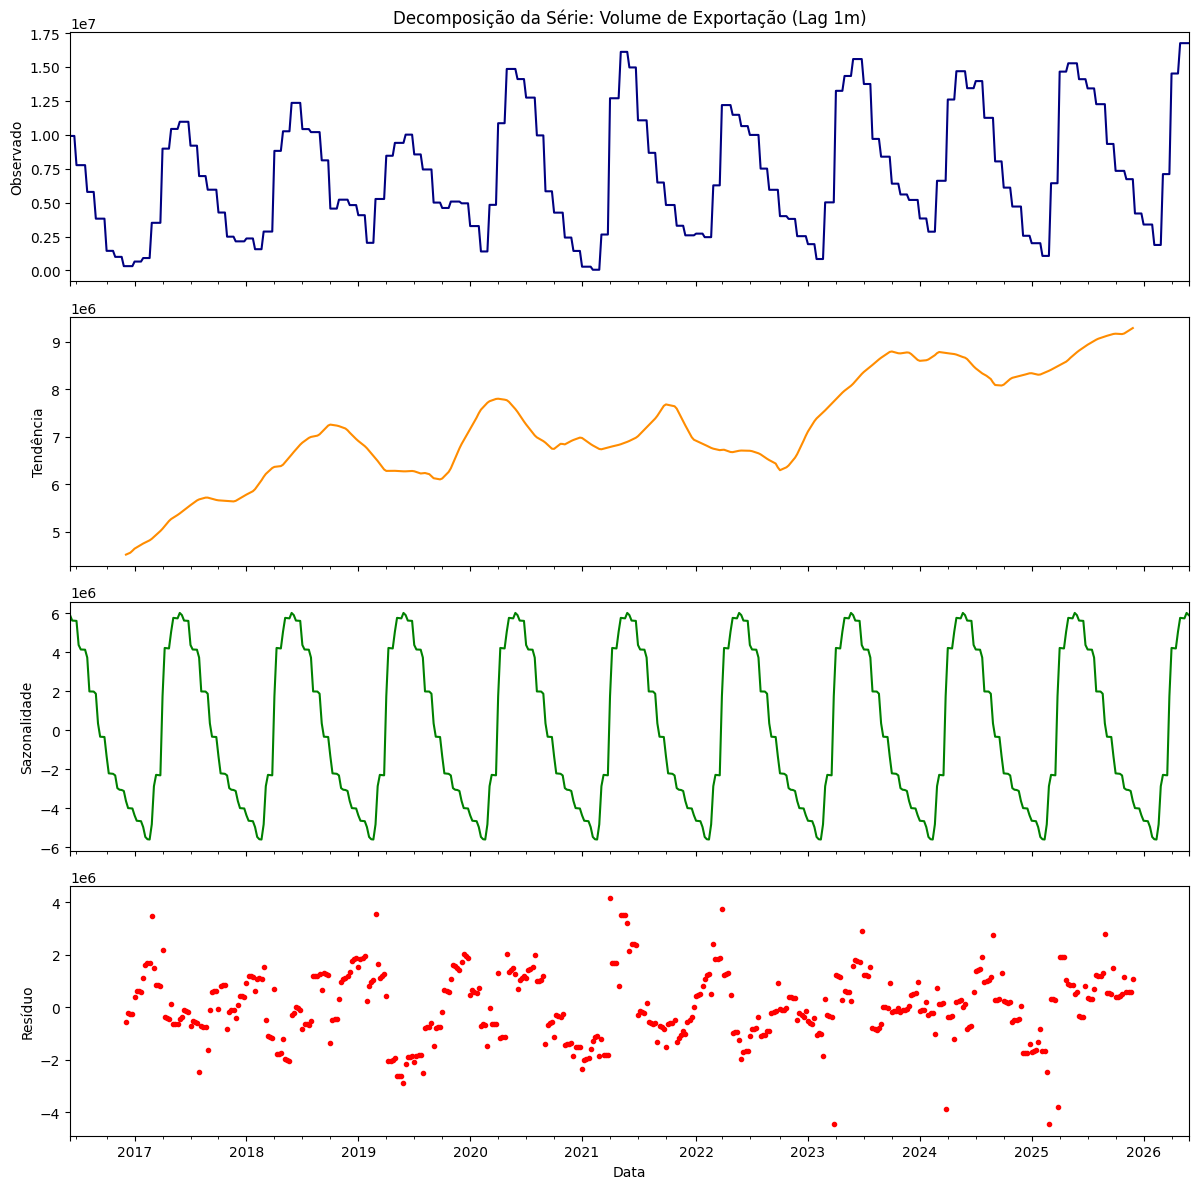

In [47]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

decomposition.observed.plot(ax=ax1, color='navy')
ax1.set_ylabel('Observado')
ax1.set_title('Decomposição da Série: Volume de Exportação (Lag 1m)')

decomposition.trend.plot(ax=ax2, color='darkorange')
ax2.set_ylabel('Tendência')

decomposition.seasonal.plot(ax=ax3, color='green')
ax3.set_ylabel('Sazonalidade')

decomposition.resid.plot(ax=ax4, color='red', style='.')
ax4.set_ylabel('Resíduo')

plt.xlabel('Data')
plt.tight_layout()
plt.show()

## CONAB

In [46]:
base.head()

,semana,preco_rs_medio,preco_rs_fechamento,preco_usd_medio,preco_usd_fechamento,retorno_rs_1w,retorno_usd_1w,dolar_medio_semana,dolar_fechamento_semana,chuva_soja_1w,...,periodo_critico_soja,export_volume_ton_lag_1m,export_valor_fob_usd_lag_1m,export_preco_implicito_usd_ton_lag_1m,safra_ref,conab_area_mil_ha,conab_produtividade_kg_ha,conab_producao_mil_ton,ano,mes_nome
0,2016-06-10,96.100,96.88,28.044,28.26,0.006441,0.035544,3.43638,3.4261,17.4756,...,0,9915098.848,3600309132,363.113791,2015/16,33251.9,2877.958999,95697.60484,2016,6
1,2016-06-17,97.100,96.78,28.026,28.28,-0.001032,0.000708,3.46832,3.4372,2.0682,...,0,9915098.848,3600309132,363.113791,2015/16,33251.9,2877.958999,95697.60484,2016,6
2,2016-06-24,94.408,92.66,27.936,27.46,-0.042571,-0.028996,3.37840,3.3772,3.0711,...,0,9915098.848,3600309132,363.113791,2015/16,33251.9,2877.958999,95697.60484,2016,6
3,2016-07-01,92.968,92.31,28.384,28.57,-0.003777,0.040422,3.28064,3.2298,0.0401,...,0,7761036.427,2971369089,382.857253,2015/16,33251.9,2877.958999,95697.60484,2016,7
4,2016-07-08,90.066,87.65,27.218,26.66,-0.050482,-0.066853,3.29964,3.2968,4.6174,...,0,7761036.427,2971369089,382.857253,2015/16,33251.9,2877.958999,95697.60484,2016,7


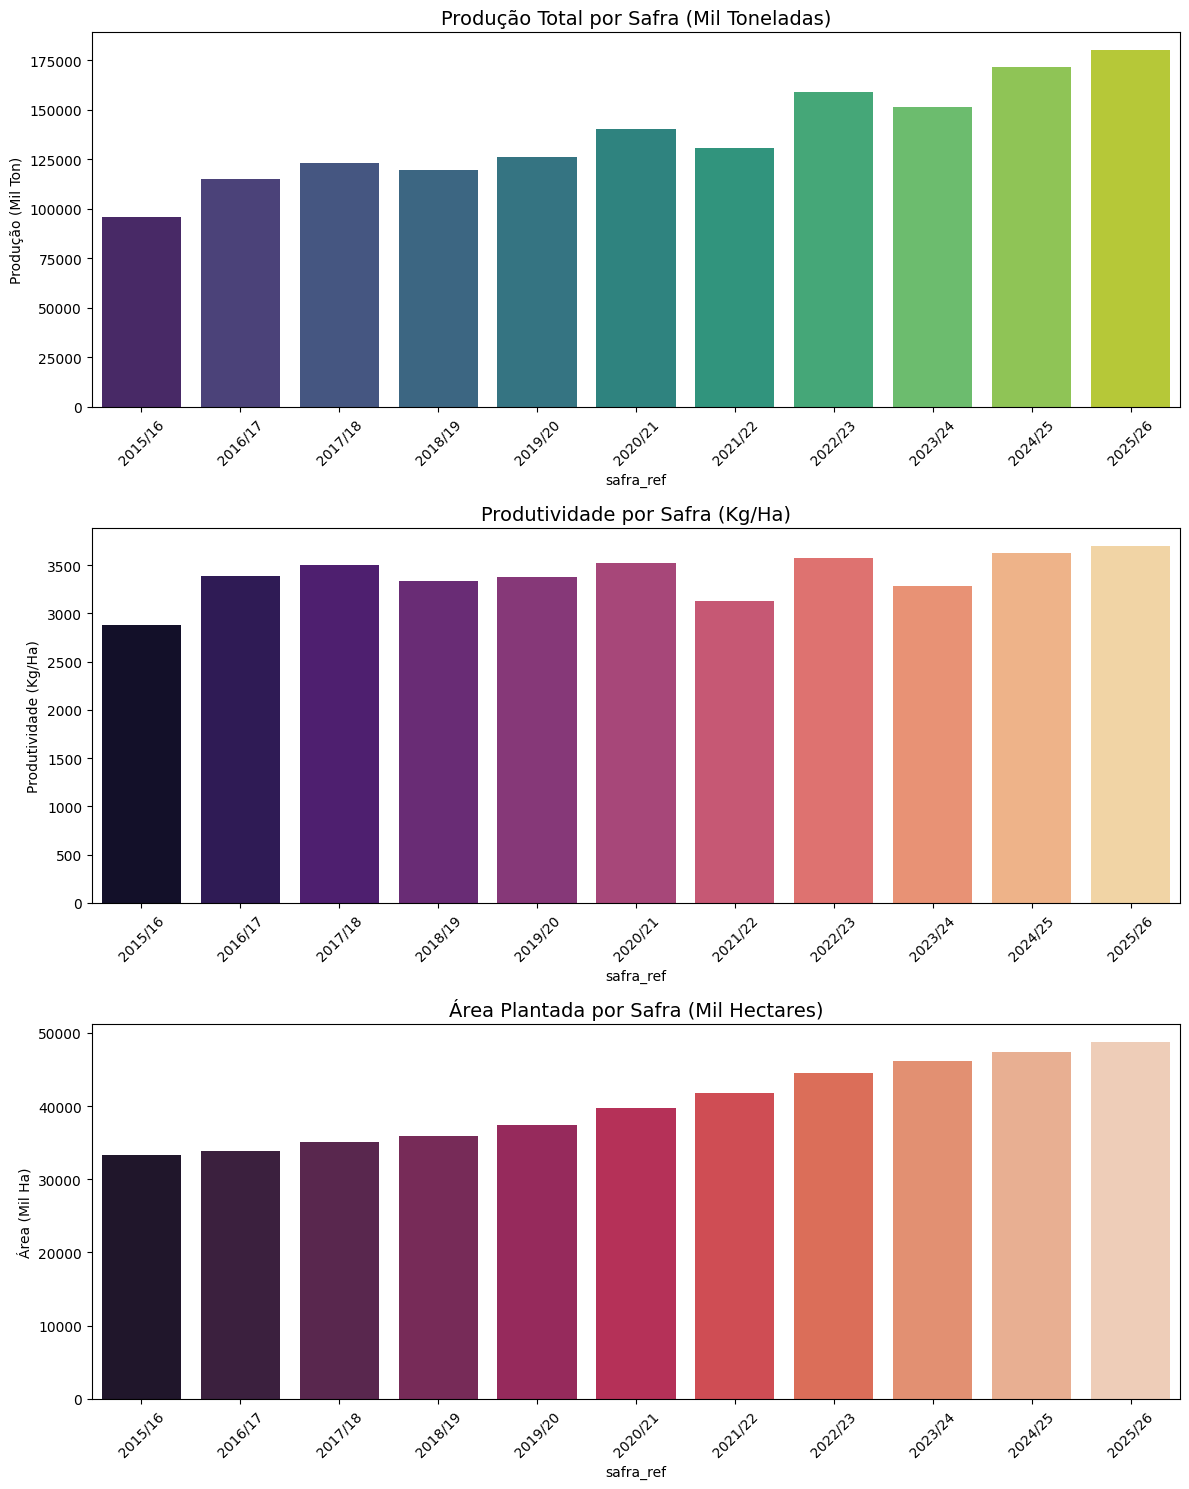

In [48]:
# Agrupando os dados por safra para garantir que pegamos os valores únicos de cada ciclo
conab_safra = base.groupby('safra_ref')[['conab_producao_mil_ton', 'conab_produtividade_kg_ha', 'conab_area_mil_ha']].mean().reset_index()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))

# 1. Produção por Safra
sns.barplot(data=conab_safra, x='safra_ref', y='conab_producao_mil_ton', ax=ax1, palette='viridis', hue='safra_ref', legend=False)
ax1.set_title('Produção Total por Safra (Mil Toneladas)', fontsize=14)
ax1.set_ylabel('Produção (Mil Ton)')
ax1.tick_params(axis='x', rotation=45)

# 2. Produtividade por Safra
sns.barplot(data=conab_safra, x='safra_ref', y='conab_produtividade_kg_ha', ax=ax2, palette='magma', hue='safra_ref', legend=False)
ax2.set_title('Produtividade por Safra (Kg/Ha)', fontsize=14)
ax2.set_ylabel('Produtividade (Kg/Ha)')
ax2.tick_params(axis='x', rotation=45)

# 3. Área por Safra
sns.barplot(data=conab_safra, x='safra_ref', y='conab_area_mil_ha', ax=ax3, palette='rocket', hue='safra_ref', legend=False)
ax3.set_title('Área Plantada por Safra (Mil Hectares)', fontsize=14)
ax3.set_ylabel('Área (Mil Ha)')
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Clima

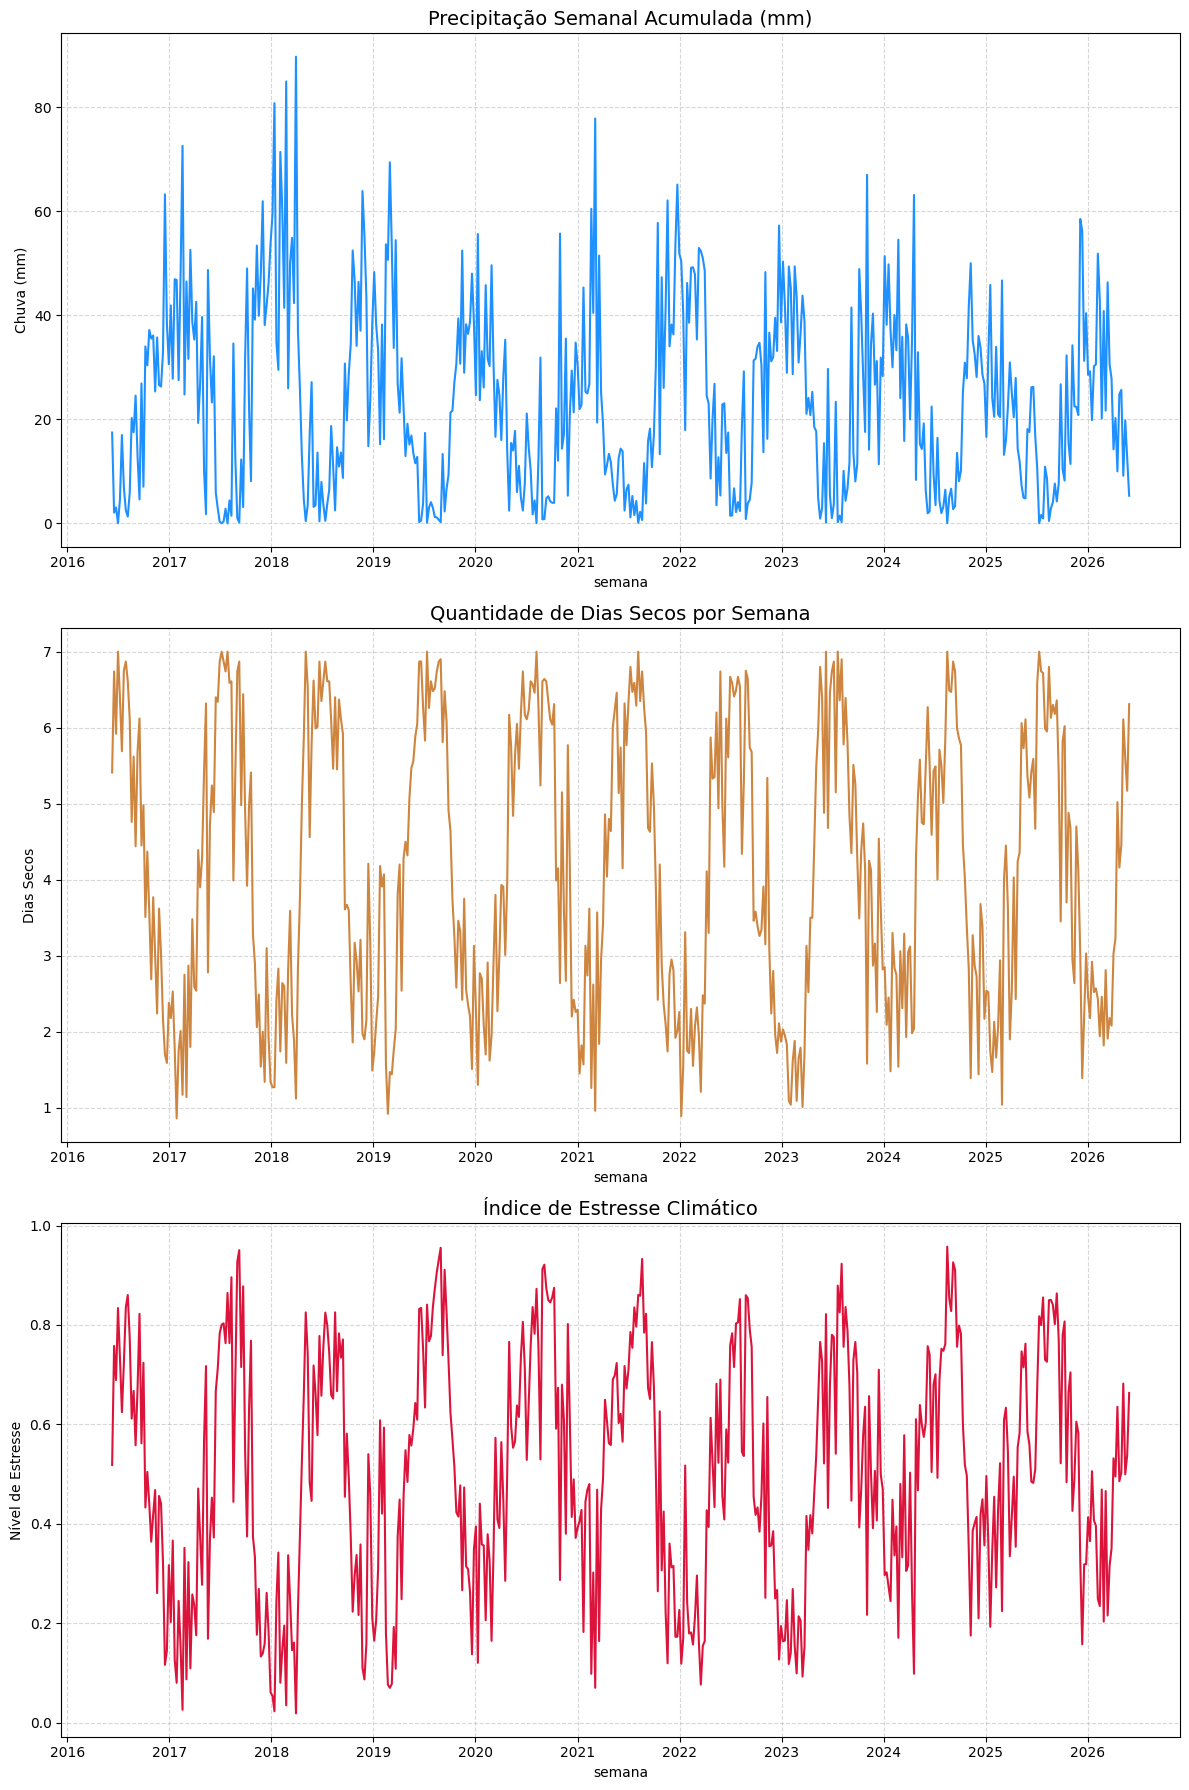

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando uma figura para análise climática
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 18))

# 1. Precipitação Semanal
sns.lineplot(data=base, x='semana', y='chuva_soja_1w', ax=ax1, color='dodgerblue')
ax1.set_title('Precipitação Semanal Acumulada (mm)', fontsize=14)
ax1.set_ylabel('Chuva (mm)')
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Dias Secos na Semana
sns.lineplot(data=base, x='semana', y='dias_secos_soja_1w', ax=ax2, color='peru')
ax2.set_title('Quantidade de Dias Secos por Semana', fontsize=14)
ax2.set_ylabel('Dias Secos')
ax2.grid(True, linestyle='--', alpha=0.5)

# 3. Índice de Estresse Climático
sns.lineplot(data=base, x='semana', y='stress_climatico_soja', ax=ax3, color='crimson')
ax3.set_title('Índice de Estresse Climático', fontsize=14)
ax3.set_ylabel('Nível de Estresse')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

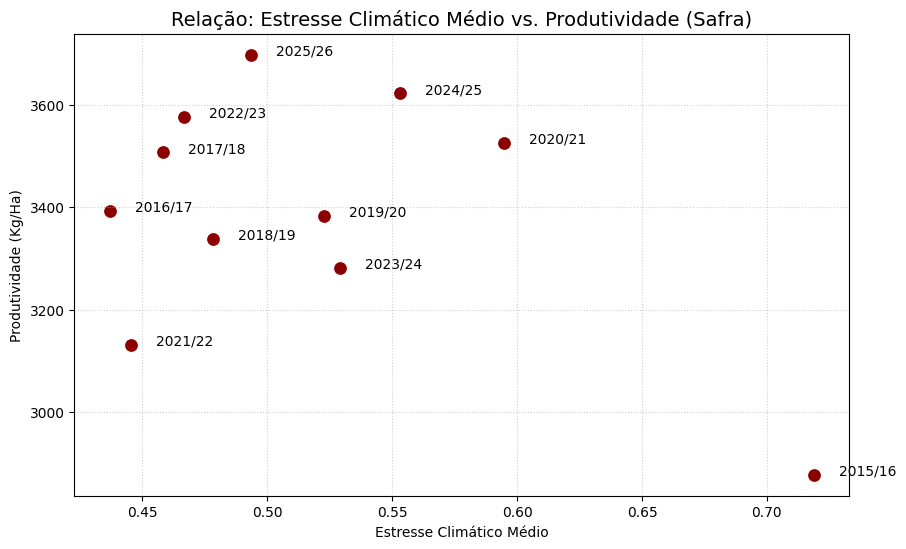

In [50]:
# Calculando a correlação entre estresse climático e produtividade por safra
clima_safra = base.groupby('safra_ref')[['stress_climatico_soja', 'conab_produtividade_kg_ha']].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=clima_safra, x='stress_climatico_soja', y='conab_produtividade_kg_ha', s=100, color='darkred')
for i, row in clima_safra.iterrows():
    plt.text(row['stress_climatico_soja']+0.01, row['conab_produtividade_kg_ha'], row['safra_ref'])

plt.title('Relação: Estresse Climático Médio vs. Produtividade (Safra)', fontsize=14)
plt.xlabel('Estresse Climático Médio')
plt.ylabel('Produtividade (Kg/Ha)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# **Relações**

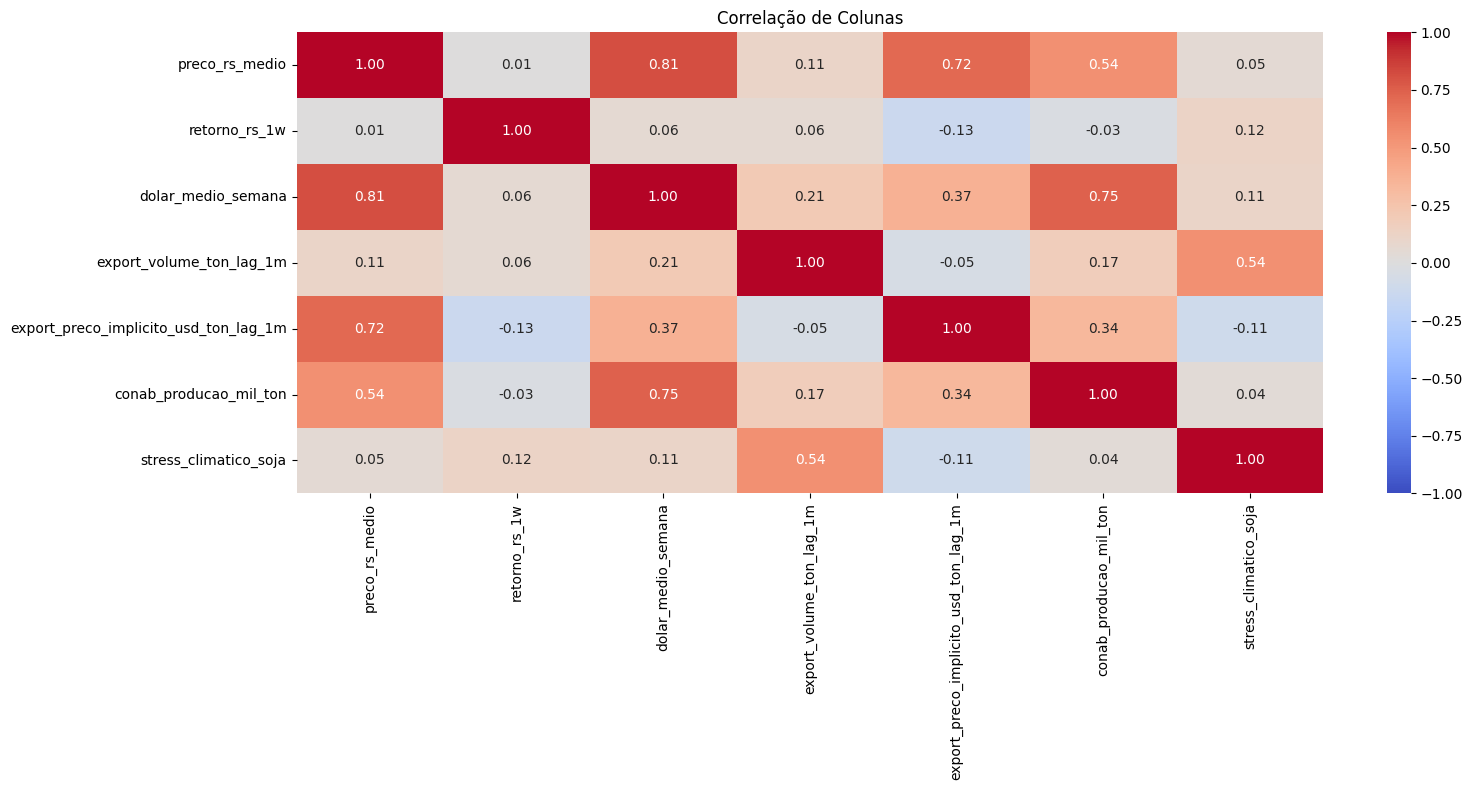

In [53]:
col_base_cor = ['preco_rs_medio', 'retorno_rs_1w', 'dolar_medio_semana', 'export_volume_ton_lag_1m', 'export_preco_implicito_usd_ton_lag_1m', 'conab_producao_mil_ton', 'stress_climatico_soja']

base_correlacao = base[col_base_cor].corr()

plt.figure(figsize=(16, 8))
sns.heatmap(base_correlacao, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)

plt.title('Correlação de Colunas')
plt.tight_layout()
plt.show()

## Preço x Dolar

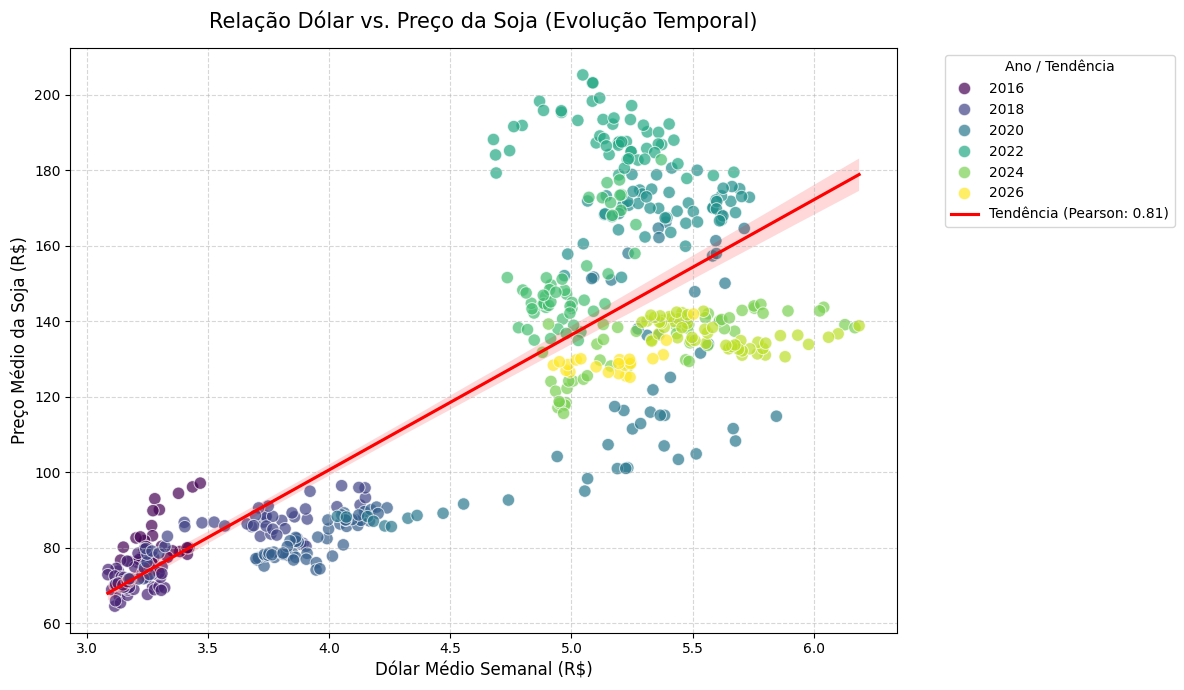

In [58]:
plt.figure(figsize=(12, 7))

# Cálculo da correlação de Pearson
corr_val = base['dolar_medio_semana'].corr(base['preco_rs_medio'])

# Gráfico de dispersão com cores por ano
scatter = sns.scatterplot(
    data=base,
    x='dolar_medio_semana',
    y='preco_rs_medio',
    hue=base['semana'].dt.year,
    palette='viridis',
    alpha=0.7,
    s=80
)

# Linha de tendência (Regressão Linear)
sns.regplot(
    data=base,
    x='dolar_medio_semana',
    y='preco_rs_medio',
    scatter=False,
    color='red',
    label=f'Tendência (Pearson: {corr_val:.2f})'
)

plt.title('Relação Dólar vs. Preço da Soja (Evolução Temporal)', fontsize=15, pad=15)
plt.xlabel('Dólar Médio Semanal (R$)', fontsize=12)
plt.ylabel('Preço Médio da Soja (R$)', fontsize=12)
plt.legend(title='Ano / Tendência', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Preço x Exportações

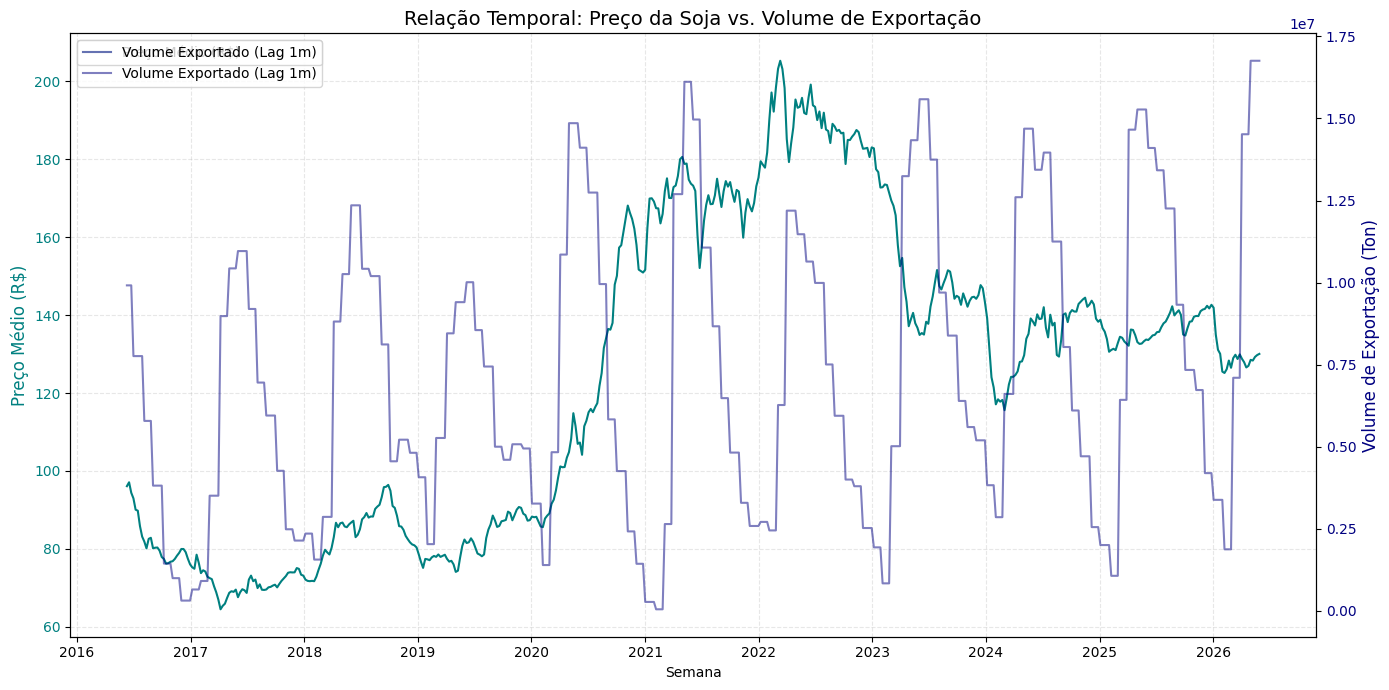

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando o gráfico de eixos duplos para comparação temporal
fig, ax1 = plt.subplots(figsize=(14, 7))

# Eixo 1: Preço Médio
color_price = 'teal'
sns.lineplot(data=base, x='semana', y='preco_rs_medio', ax=ax1, color=color_price, label='Preço Médio (R$)')
ax1.set_xlabel('Semana')
ax1.set_ylabel('Preço Médio (R$)', color=color_price, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_price)
ax1.grid(True, linestyle='--', alpha=0.3)

# Eixo 2: Volume de Exportação
ax2 = ax1.twinx()
color_vol = 'navy'
sns.lineplot(data=base, x='semana', y='export_volume_ton_lag_1m', ax=ax2, color=color_vol, alpha=0.5, label='Volume Exportado (Lag 1m)')
ax2.set_ylabel('Volume de Exportação (Ton)', color=color_vol, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_vol)

plt.title('Relação Temporal: Preço da Soja vs. Volume de Exportação', fontsize=14)

# Ajustando as legendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

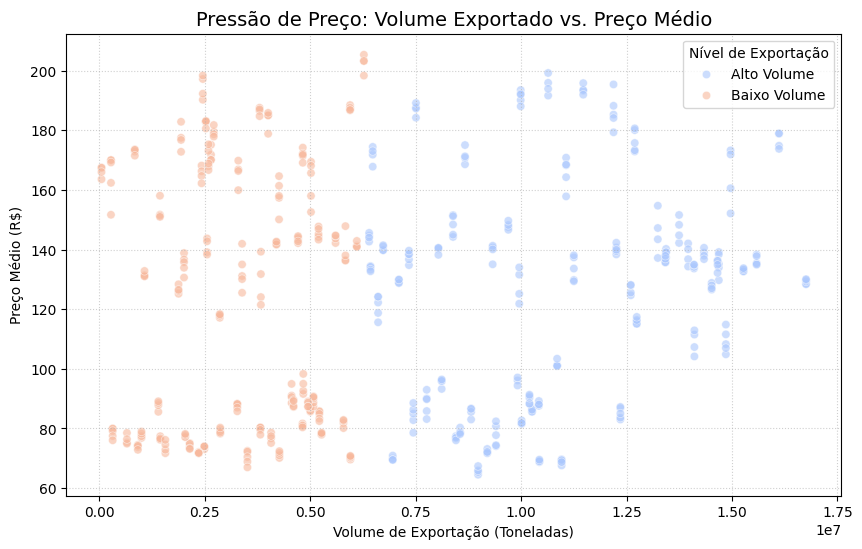

Correlação entre Preço R$ e Volume de Exportação: 0.11


In [60]:
# Gráfico de Dispersão para ver a 'pressão' de volume sobre o preço
plt.figure(figsize=(10, 6))

# Categorizando o volume em 'Alto' e 'Baixo' baseado na mediana para facilitar a visualização da pressão
mediana_vol = base['export_volume_ton_lag_1m'].median()
base['nivel_exportacao'] = base['export_volume_ton_lag_1m'].apply(lambda x: 'Alto Volume' if x > mediana_vol else 'Baixo Volume')

sns.scatterplot(data=base, x='export_volume_ton_lag_1m', y='preco_rs_medio', hue='nivel_exportacao', palette='coolwarm', alpha=0.6)

plt.title('Pressão de Preço: Volume Exportado vs. Preço Médio', fontsize=14)
plt.xlabel('Volume de Exportação (Toneladas)')
plt.ylabel('Preço Médio (R$)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Nível de Exportação')
plt.show()

# Calculando a correlação específica entre essas duas variáveis
corr_pre_exp = base['preco_rs_medio'].corr(base['export_volume_ton_lag_1m'])
print(f'Correlação entre Preço R$ e Volume de Exportação: {corr_pre_exp:.2f}')

## Preço x Clima

--- Média de Estresse por Período Crítico ---


,stress_climatico_soja
periodo_critico_soja,
0,0.661761
1,0.375453
3,0.277370



--- Média de Retorno Semanal por Período Crítico ---


,retorno_rs_1w
periodo_critico_soja,
0,0.002544
1,-0.000422
3,-0.001755


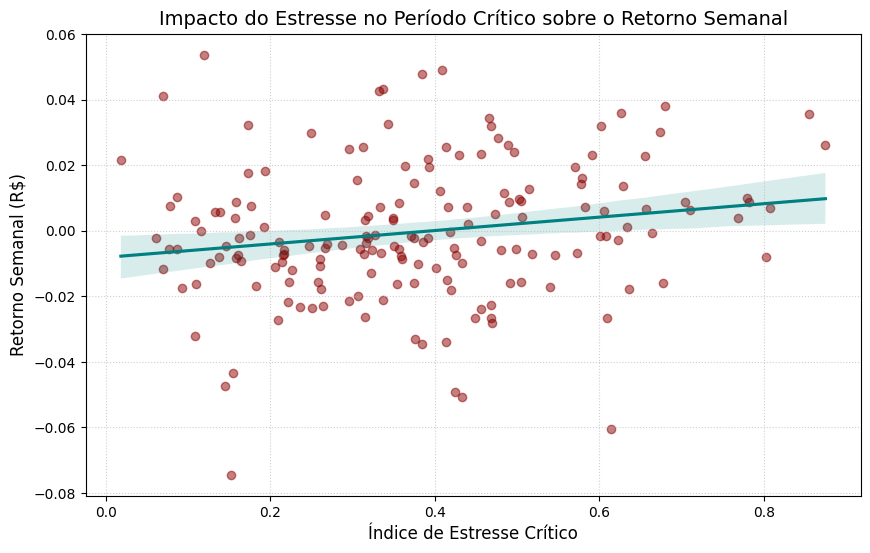

Correlação no período crítico: 0.18


In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Análise 1: Médias Agrupadas pelo Período Crítico
print("--- Média de Estresse por Período Crítico ---")
display(base.groupby('periodo_critico_soja')['stress_climatico_soja'].mean())

print("\n--- Média de Retorno Semanal por Período Crítico ---")
display(base.groupby('periodo_critico_soja')['retorno_rs_1w'].mean())

# Criando a variável de interação
base['stress_critico'] = base['stress_climatico_soja'] * base['periodo_critico_soja']

# Gráfico: Stress Crítico versus Retorno
plt.figure(figsize=(10, 6))
sns.regplot(data=base[base['periodo_critico_soja'] == 1], x='stress_critico', y='retorno_rs_1w',
            scatter_kws={'alpha':0.5, 'color':'darkred'}, line_kws={'color':'teal'})

plt.title('Impacto do Estresse no Período Crítico sobre o Retorno Semanal', fontsize=14)
plt.xlabel('Índice de Estresse Crítico', fontsize=12)
plt.ylabel('Retorno Semanal (R$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Correlação no período crítico
corr_stress = base[base['periodo_critico_soja'] == 1][['stress_critico', 'retorno_rs_1w']].corr().iloc[0,1]
print(f'Correlação no período crítico: {corr_stress:.2f}')